# Notebook Dedicated to Study the Directional Pattern of the Solar Candidates

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, ScalarFormatter
from matplotlib import font_manager

import seaborn as sn
import glob

# Load Data

## Load the ntuple Info

In [26]:
main_dir = '/home/joankl/data/solars/real_data/bisMSB/first_candidates/analysis*/resume_files/'
obs_list_ntuple = ['eventID', 'energy_corrected', 'posr_av']
obs_dict_ntuple = {var_i: np.array([]) for var_i in obs_list_ntuple}

for obs_i in obs_list_ntuple:
    flist = glob.glob(main_dir + obs_i + '.npy') # List of directories where the obs is

    for f_i in flist:
        array_i = np.load(f_i)
        obs_dict_ntuple[obs_i] = np.append(obs_dict_ntuple[obs_i], array_i)

# Apply Cut
en_cut = 5.0

condition = (obs_dict_ntuple['energy_corrected'] >= en_cut)

evtid_ntuple = obs_dict_ntuple['eventID'][condition]
energy = obs_dict_ntuple['energy_corrected'][condition]

## Load the numpy from RATDS Info and Perform Time Residual Cut

In [2]:
#main_dir = '/home/joankl/data/solars/real_data/bisMSB/first_candidates/analysis*/ratds_output/np_files/'
main_dir = 'E:/Data/solars/solarnu_Realdata/2p2PPO/first_candidates/ratds/np_files/'
obs_list_ratds = ['cos_alpha', 'evtid', 'energy_corr', 'posr', 'hit_residual']
obs_dict_ratds = {var_i: np.array([]) for var_i in obs_list_ratds}

for obs_i in obs_list_ratds:
    flist = glob.glob(main_dir + obs_i + '*.npy')

    for f_i in flist:
        array_i = np.load(f_i)
        obs_dict_ratds[obs_i] = np.append(obs_dict_ratds[obs_i], array_i)

cos_alpha = obs_dict_ratds['cos_alpha']
time_res = obs_dict_ratds['hit_residual']
energy = obs_dict_ratds['energy_corr']
posr = obs_dict_ratds['posr']
evtid_ratds = obs_dict_ratds['evtid']

In [3]:
min(energy)

4.7904205322265625

In [4]:
min(time_res)

-146.86537170410156

# Extract the Unique eventID (non per hit)

# Directionality Plot

In [5]:
save_path = 'figs/above_5_MeV_solar_results/'

font_style_title = {'family':'serif', 'weight': 'normal','color':'black','size':13}
font_style_axis= {'family':'serif', 'weight': 'normal','color':'black','size':12}
font_prop = font_manager.FontProperties(family=font_style_axis['family'], weight=font_style_axis['weight'], size=font_style_axis['size'])

## Plots with a Fix Time Residual

In [31]:
# ------ Time Residual Cut ------
t_res_min = -5
t_res_max = 1

tres_condition = (time_res >= t_res_min) & (time_res <= t_res_max)

cos_alpha_cut_tres = cos_alpha[tres_condition]
energy_cut_tres = energy[tres_condition]
posr_cut_tres = posr[tres_condition]

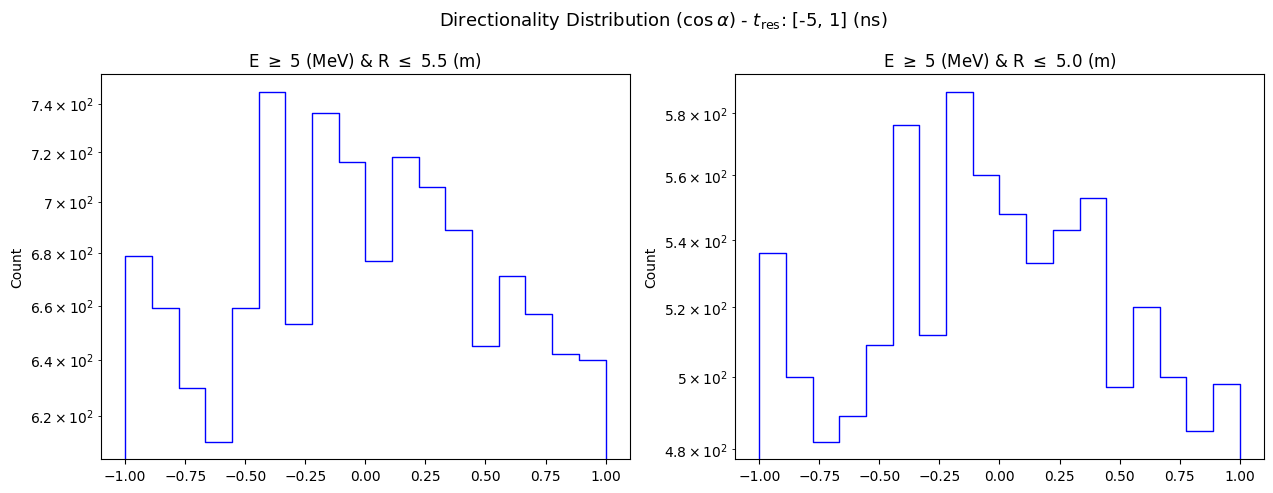

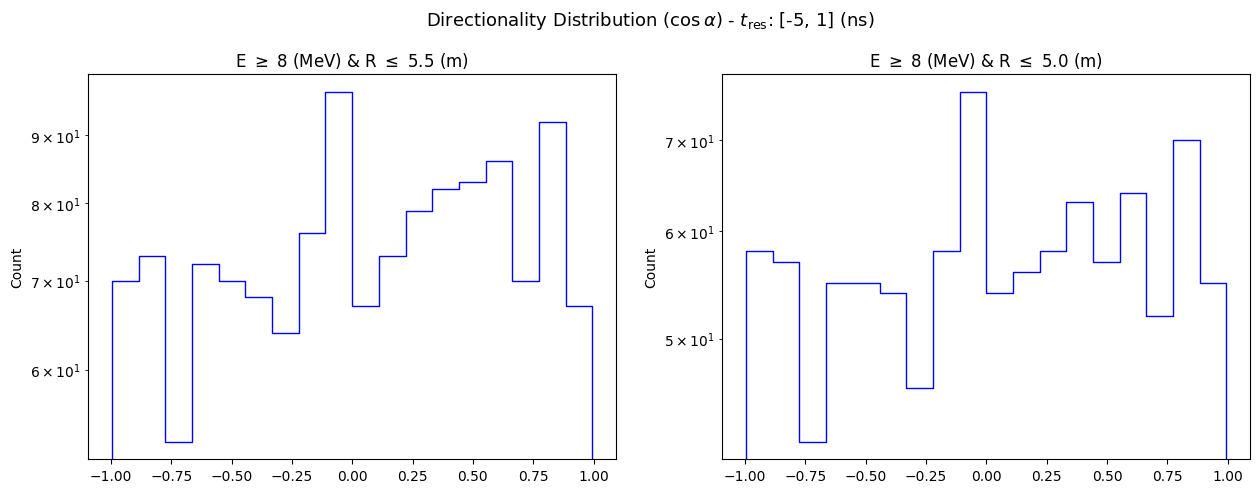

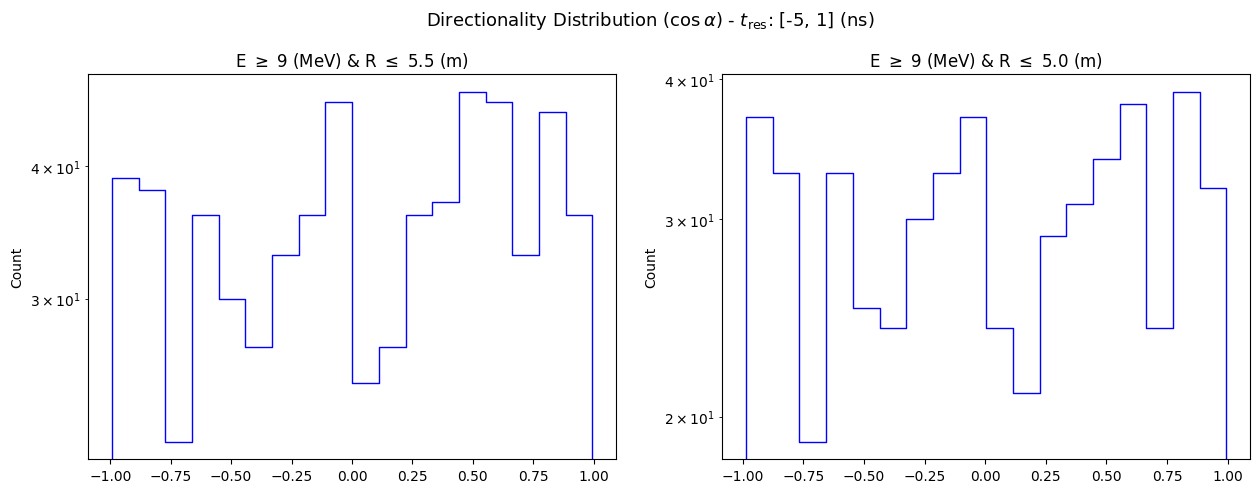

In [32]:
bins = 18
# ------ Define Cuts ------
E_cut_list = [5, 8, 9]
R_cut_list = [5500, 5000]

for j_dx, Ecut_i in enumerate(E_cut_list):
    en_cut_condition = (energy_cut_tres >= Ecut_i)
    
    fig, axes = plt.subplots(1, len(R_cut_list), figsize=(15, 5))
    
    for i_dx, Rcut_i in enumerate(R_cut_list):
        posr_cut_condition = (posr_cut_tres <= Rcut_i)
        cut_condition = en_cut_condition & posr_cut_condition
        
        cos_alpha_cut = cos_alpha_cut_tres[cut_condition]
        
        ax = axes[i_dx]
    
        sn.histplot(cos_alpha_cut, ax = ax, bins = bins, alpha = 0, element = 'step', color = 'blue')

        ax.set_title(fr'E $\geq$ {Ecut_i} (MeV) & R $\leq$ {Rcut_i*10**(-3)} (m)')
        ax.set_yscale('log')

    plt.suptitle(fr'Directionality Distribution ($\cos\alpha$) - $t_\mathrm{{res}}$: [{t_res_min:.0f}, {t_res_max:.0f}] (ns)', fontsize = 13, y = 1.01)

    plt.show()

## Plots with Varying Time Residual

C:\Users\joanc\AppData\Local\Temp\ipykernel_24936\3514953978.py:57: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 0.7)


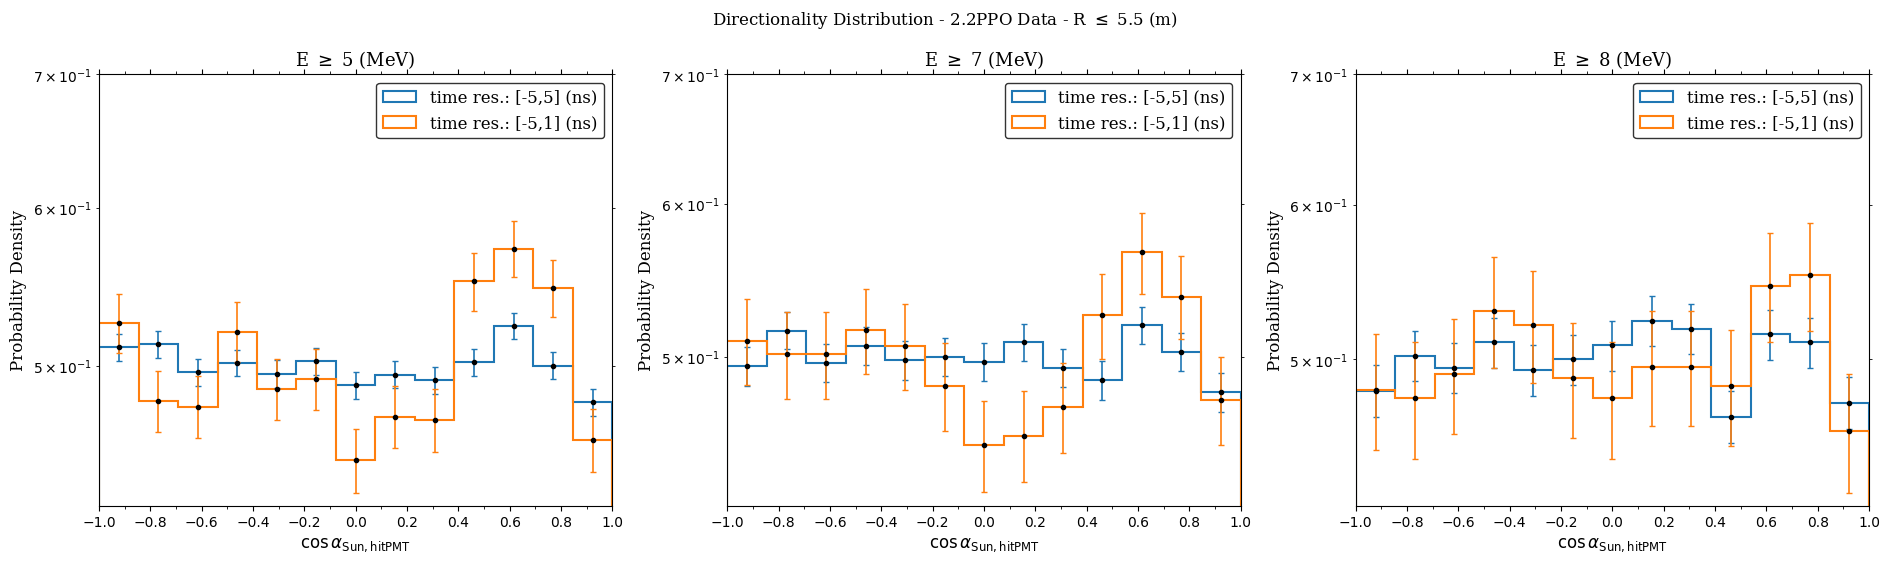

In [7]:
# ------ Define the Cuts ------
E_cut_list = [5, 7, 8]
t_res_cut_list = [(-5,5), (-5,1)]
# -----------------------------

bins = 13
bin_edges = np.linspace(-1.0, 1.0, bins + 1)

# Compute bincenter and binwidth
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

hist_data = {energy:{tres: np.zeros(bins) for tres in t_res_cut_list} for energy in E_cut_list}

for en_cut_i in E_cut_list:
    energy_mask = (energy >= en_cut_i)
    
    for t_res_cut_i in t_res_cut_list:     
        tres_mask = (time_res >= t_res_cut_i[0]) & (time_res <= t_res_cut_i[1]) 
        general_mask = energy_mask & tres_mask

        counts, _ = np.histogram(cos_alpha[general_mask], bins=bin_edges)
        hist_data[en_cut_i][t_res_cut_i] += counts

# --- Configuración de fuentes y plot ---
fig, axes = plt.subplots(1, len(E_cut_list), figsize = (19, 5.7))

for idx, en_cut_i in enumerate(E_cut_list):
    ax = axes[idx]
    
    for t_res_cut_i in t_res_cut_list:
        counts = hist_data[en_cut_i][t_res_cut_i]
        plt_label = f'time res.: [{t_res_cut_i[0]},{t_res_cut_i[1]}] (ns)'

        # 1. Trazar el Step y capturar sus propiedades
        _, _, patches = ax.hist(bin_edges[:-1], bins=bin_edges, weights=counts, density=True, histtype='step', linewidth=1.5, label = plt_label)
        
        # Extraemos el color que Matplotlib le asignó a esta línea
        line_color = patches[0].get_edgecolor()

        # 2. Calcular los valores de PDF y los Errores de Poisson propagados
        total_counts = np.sum(counts)
        if total_counts > 0:
            norm_factor = total_counts * bin_width
            pdf_vals = counts / norm_factor
            pdf_errors = np.sqrt(counts) / norm_factor

            # 3. Agregar los Puntos y las Barras de Error
            # color='black' (el punto es negro), ecolor=line_color (la barra es del color del step)
            # zorder=3 asegura que los puntos siempre se dibujen por encima de las líneas
            ax.errorbar(bin_centers, pdf_vals, yerr=pdf_errors, fmt='.', color='black', ecolor=line_color, elinewidth=1.2, capsize=2, markersize=6, zorder=3)
        
    ax.set_yscale('log')
    ax.set_xlabel(r'$\cos\alpha_{\mathrm{Sun, hitPMT}}$', fontdict=font_style_axis)
    ax.set_ylabel(r'Probability Density', fontdict = font_style_axis)
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 0.7)
    
    # --- Markers ---
    ax.xaxis.set_minor_locator(MultipleLocator(0.1))
    ax.xaxis.set_major_locator(MultipleLocator(0.2))
    ax.tick_params(which='minor', top=True, bottom=True, left=True, right=True)
    ax.tick_params(which='major', top=True, bottom=True, left=True, right=True)
    ax.legend(loc = 'best', frameon = True, edgecolor='black', prop = font_prop)
    ax.set_title(rf'E $\geq$ {en_cut_i} (MeV)', fontdict = font_style_title)

plt.suptitle(rf'Directionality Distribution - 2.2PPO Data - R $\leq$ 5.5 (m)', fontdict = font_style_title)
plt.tight_layout()

plt.savefig(save_path + f'Directionality_all_Ecuts_R_5.5_m.png', dpi=300, bbox_inches='tight')
plt.show()